# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

This project performs an exploratory analysis of the Indian mutual fund industry using historical NAV, AUM, SIP, folio, investor, and portfolio data. The objective is to identify trends, patterns, investor behavior, and fund performance.

In [1]:
!pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.6 MB/s eta 0:00:00


## Importing Required Libraries

This section imports all libraries required for data analysis, visualization, and interactive plotting. These libraries will be used throughout the project.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style('whitegrid')

plt.rcParams['figure.figsize']=(12,6)

## Loading the Datasets

This step loads all mutual fund datasets into pandas DataFrames. Each dataset represents a different aspect of the mutual fund ecosystem.

In [3]:
fund = pd.read_csv('01_fund_master.csv')

nav = pd.read_csv('02_nav_history.csv')

aum = pd.read_csv('03_aum_by_fund_house.csv')

sip = pd.read_csv('04_monthly_sip_inflows.csv')

category = pd.read_csv('05_category_inflows.csv')

folio = pd.read_csv('06_industry_folio_count.csv')

performance = pd.read_csv('07_scheme_performance.csv')

investor = pd.read_csv('08_investor_transactions.csv')

holdings = pd.read_csv('09_portfolio_holdings.csv')

benchmark = pd.read_csv('10_benchmark_indices.csv')

## Dataset Exploration

This section explores the structure, dimensions, missing values, and descriptive statistics of each dataset before analysis.

In [4]:
datasets = {
    'fund':fund,
    'nav':nav,
    'aum':aum,
    'sip':sip,
    'category':category,
    'folio':folio,
    'performance':performance,
    'investor':investor,
    'holdings':holdings,
    'benchmark':benchmark
}

for name,df in datasets.items():
    print("\n")
    print("="*50)
    print(name.upper())
    print("="*50)
    print(df.columns)



FUND
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


NAV
Index(['amfi_code', 'date', 'nav'], dtype='object')


AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


CATEGORY
Index(['month', 'category', 'net_inflow_crore'], dtype='object')


FOLIO
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


PERFORMANCE
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_p

## NAV Trend Analysis (2022-2026)

This analysis studies the daily NAV movement of all mutual fund schemes and identifies periods of market expansion and correction.

In [9]:
nav['date']=pd.to_datetime(nav['date'])

nav=nav.merge(
    fund[['amfi_code','scheme_name']],
    on='amfi_code'
)

fig=px.line(
    nav,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend (2022-2026)'
)

fig.show()

## Assets Under Management (AUM) Analysis

This section analyzes the growth of assets managed by different fund houses and highlights industry leaders.

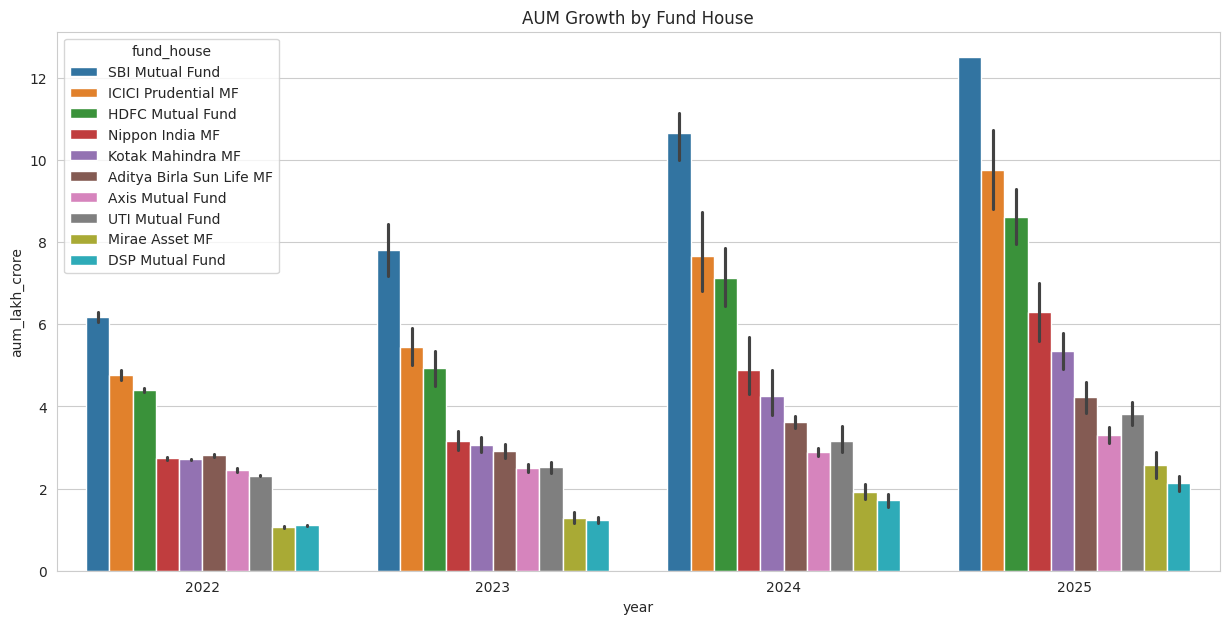

In [11]:
aum['date']=pd.to_datetime(aum['date'])

aum['year']=aum['date'].dt.year

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House')
plt.show()

## Systematic Investment Plan (SIP) Trends

This section analyzes monthly SIP inflows and identifies the record high inflow period.

In [12]:
sip['month']=pd.to_datetime(sip['month'])

fig=px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows'
)

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr'
)

fig.show()

## Category-wise Fund Inflow Analysis

This heatmap visualizes monthly net inflows across different mutual fund categories.

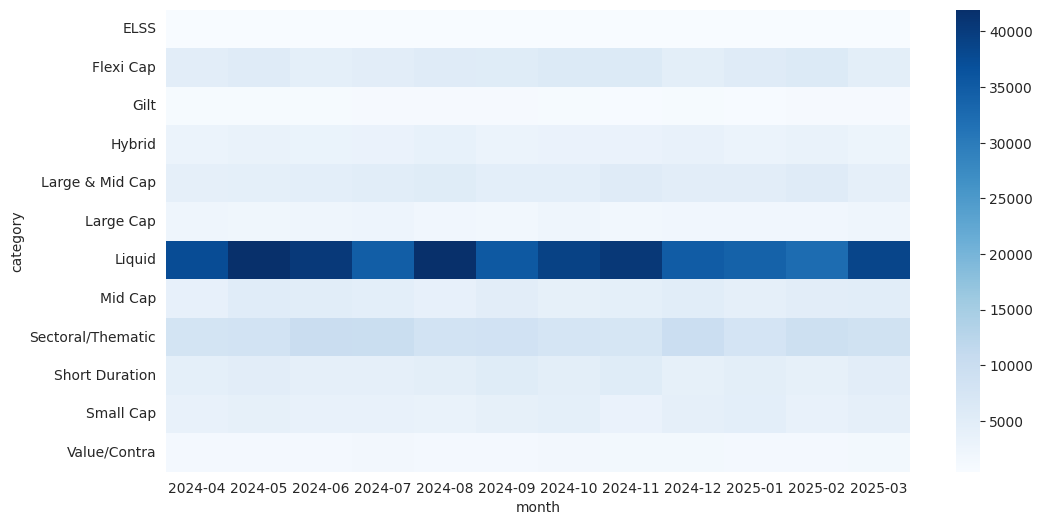

In [13]:
pivot=category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

sns.heatmap(
    pivot,
    cmap='Blues'
)

plt.show()

## Investor Demographics Analysis

This section explores investor age distribution, gender participation, and investment patterns.

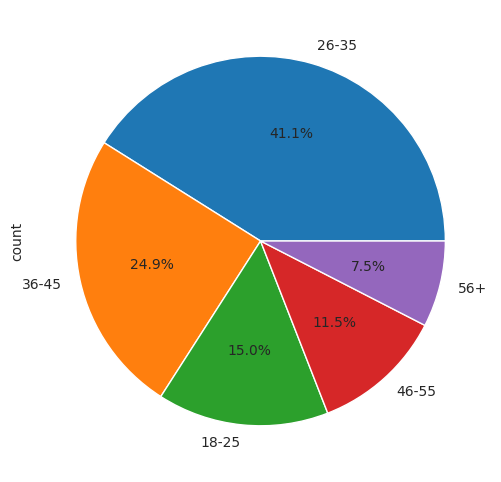

In [14]:
investor['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

#Gender Distribution

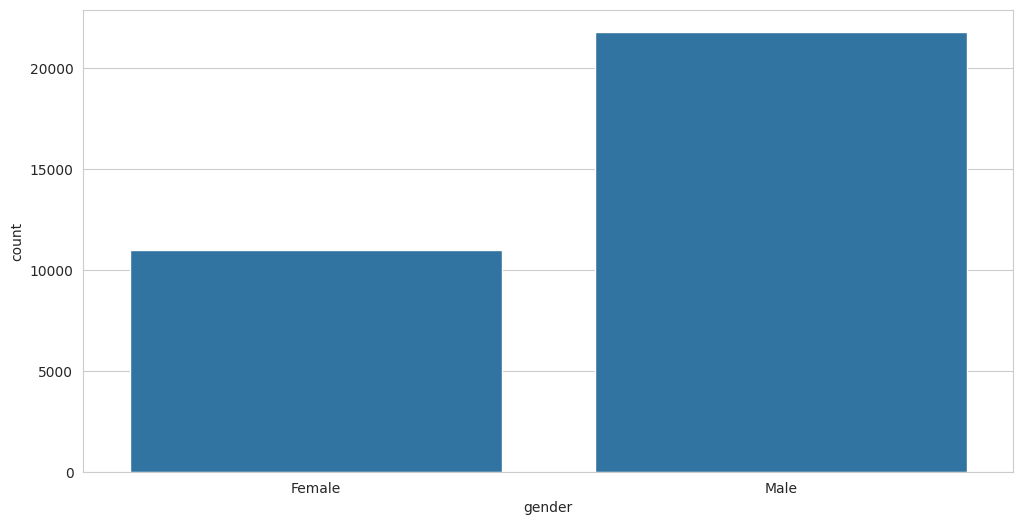

In [15]:
sns.countplot(
    data=investor,
    x='gender'
)

plt.show()

#SIP Amount Boxplot

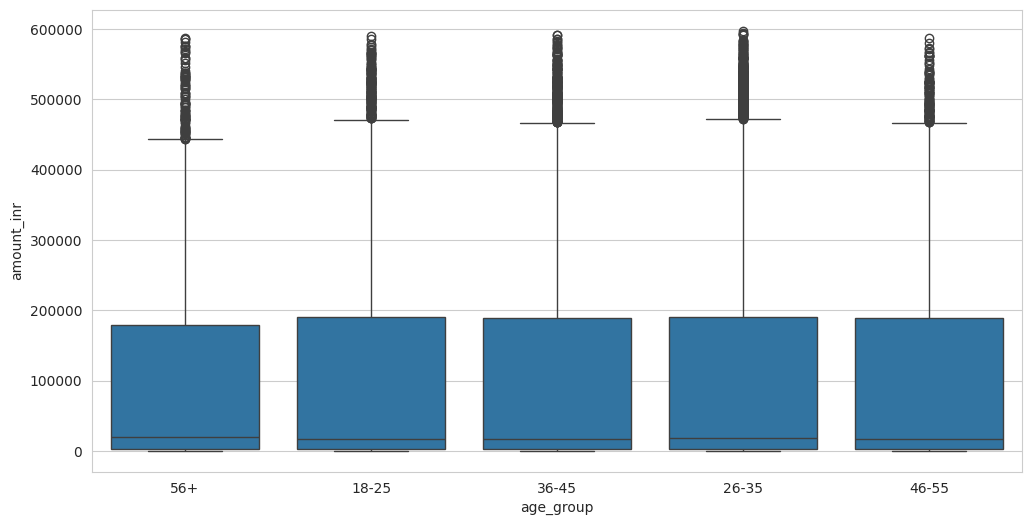

In [16]:
sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.show()

## Geographic Distribution of Investments

This analysis studies state-wise investments and compares T30 and B30 city participation.

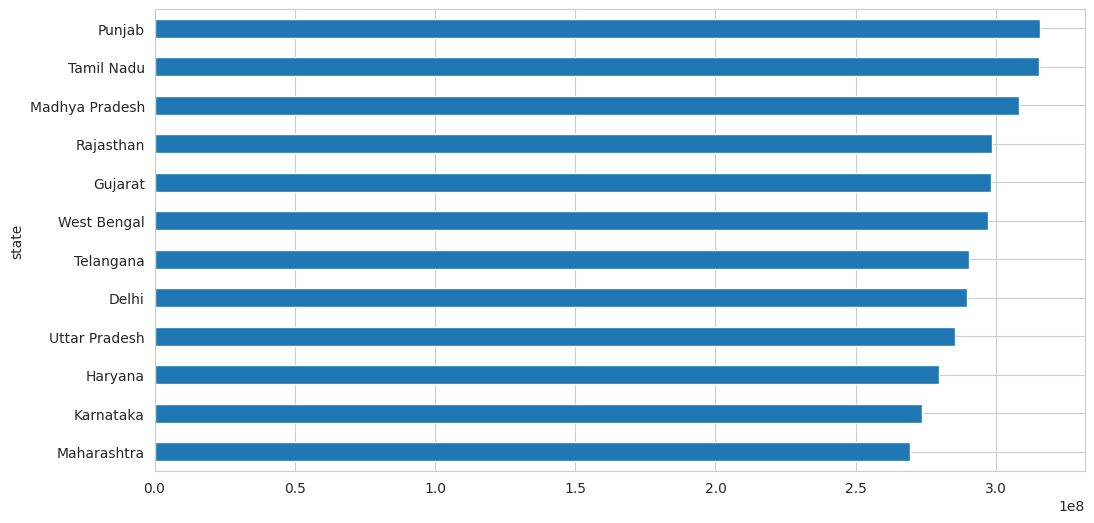

In [17]:
state=investor.groupby(
    'state'
)['amount_inr'].sum().sort_values()

state.plot(kind='barh')

plt.show()

#T30 vs B30

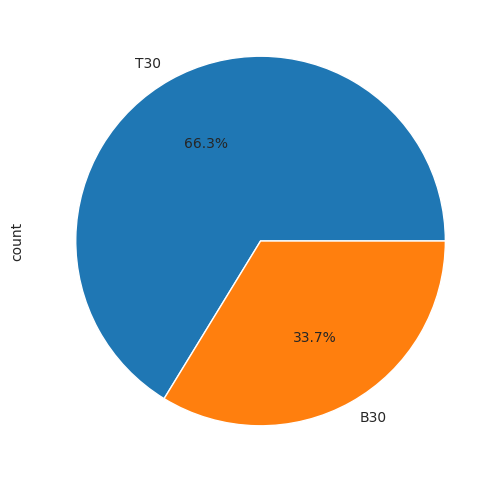

In [18]:
investor['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

## Mutual Fund Folio Growth

This section tracks the growth of investor folios between 2022 and 2025.

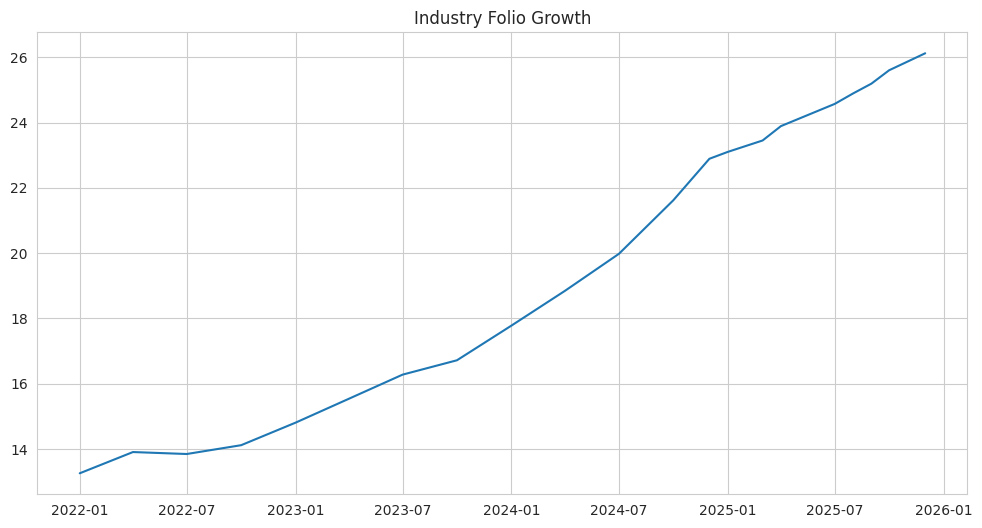

In [19]:
folio['month']=pd.to_datetime(folio['month'])

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.title('Industry Folio Growth')

plt.show()

## Mutual Fund Performance Analysis

This section evaluates the return, risk, and risk-adjusted performance of mutual fund schemes.

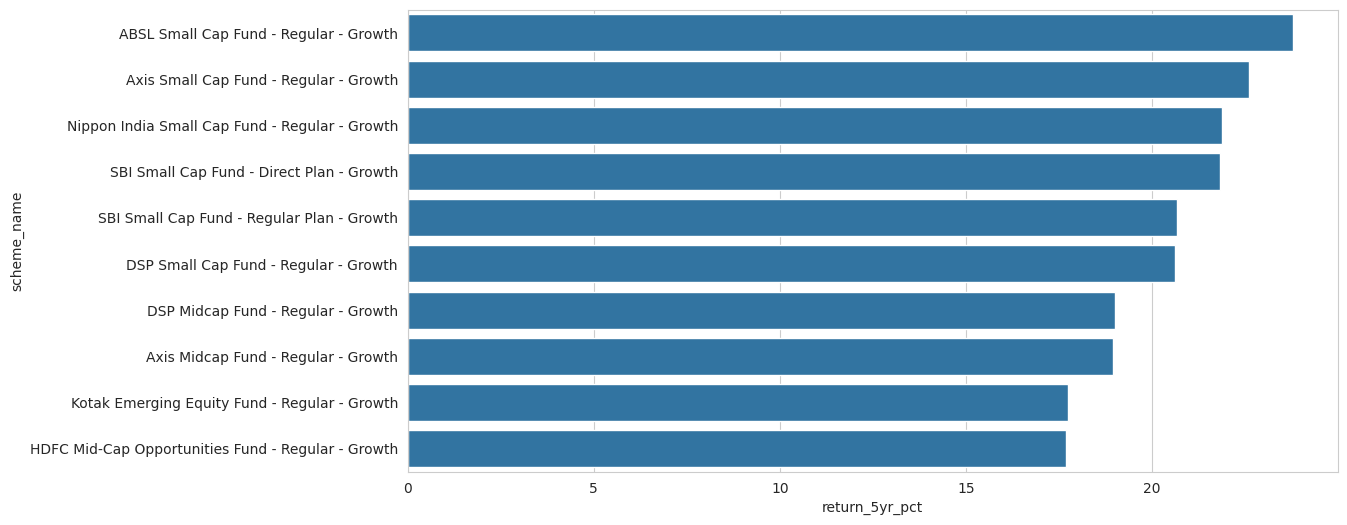

In [20]:
top=performance.nlargest(
    10,
    'return_5yr_pct'
)

sns.barplot(
    data=top,
    x='return_5yr_pct',
    y='scheme_name'
)

plt.show()

#Sharpe Ratio

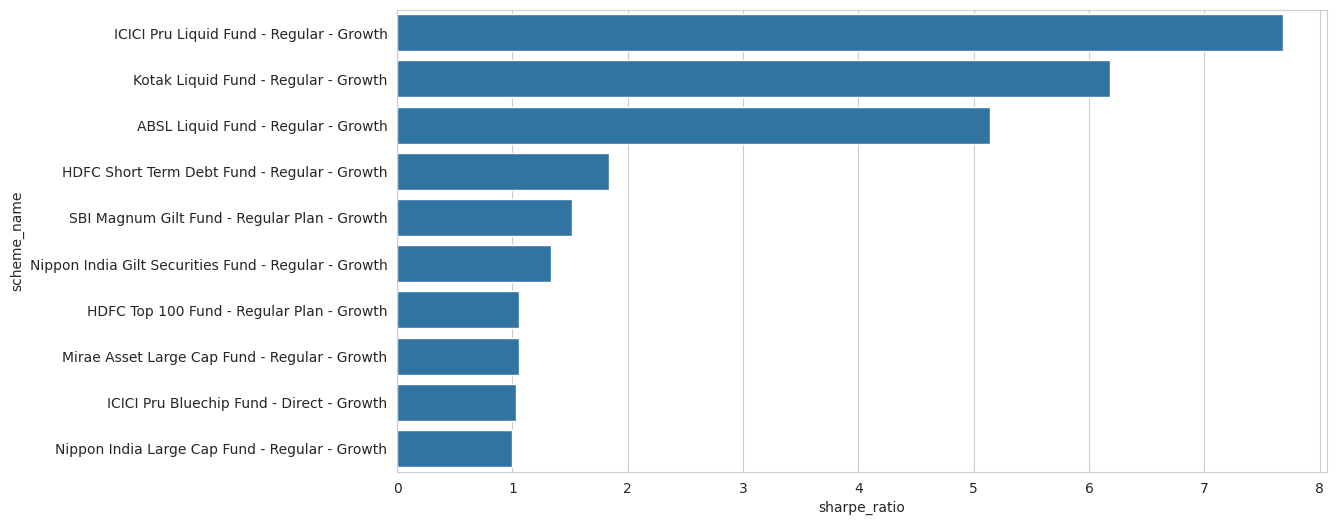

In [21]:
top=performance.nlargest(
    10,
    'sharpe_ratio'
)

sns.barplot(
    data=top,
    x='sharpe_ratio',
    y='scheme_name'
)

plt.show()

## NAV Return Correlation Matrix

This analysis identifies relationships among the returns of selected mutual funds.

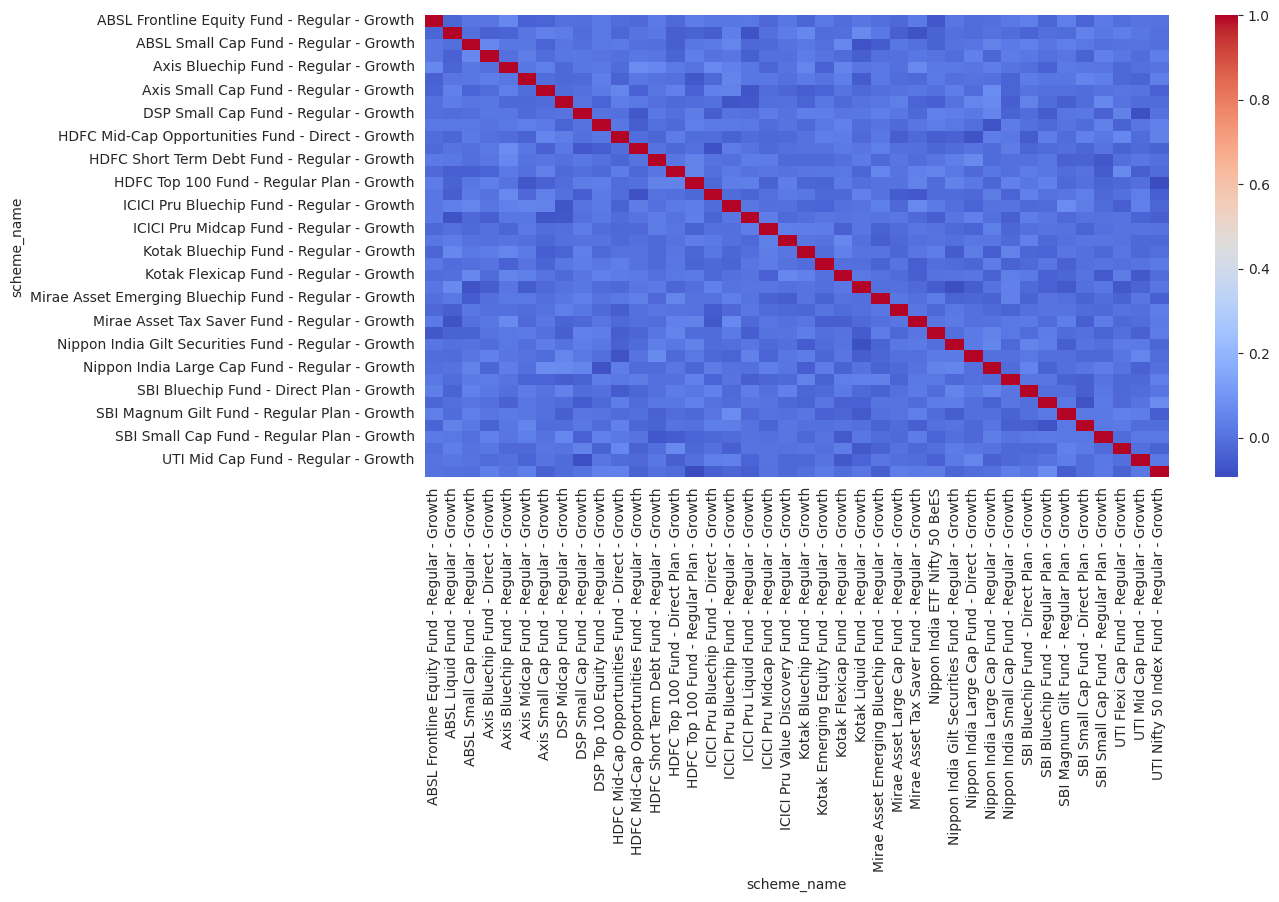

In [22]:
pivot=nav.pivot(
    index='date',
    columns='scheme_name',
    values='nav'
)

returns=pivot.pct_change()

sns.heatmap(
    returns.corr(),
    cmap='coolwarm'
)

plt.show()

## Sector Allocation Analysis

This chart visualizes the portfolio allocation across major industry sectors.

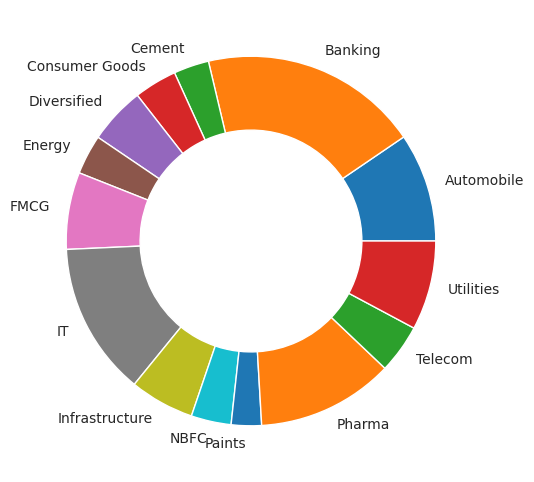

In [23]:
sector=holdings.groupby(
    'sector'
)['weight_pct'].sum()

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={'width':0.4}
)

plt.show()

## Benchmark Index Analysis

This section compares benchmark index performance over time.

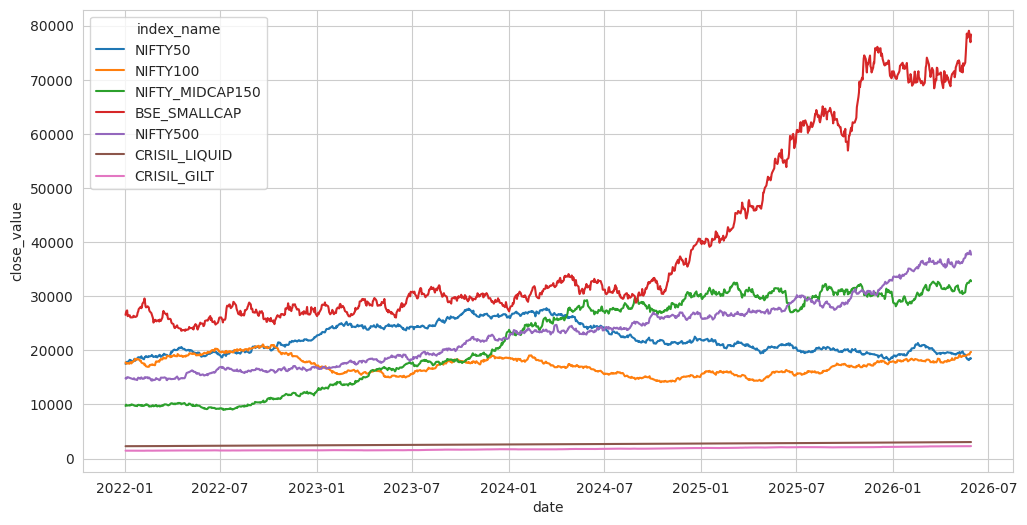

In [24]:
benchmark['date']=pd.to_datetime(
    benchmark['date']
)

sns.lineplot(
    data=benchmark,
    x='date',
    y='close_value',
    hue='index_name'
)

plt.show()

## Key Findings

1. SBI Mutual Fund maintained market leadership.
2. SIP inflows reached an all-time high in December 2025.
3. Equity folios dominated investor participation.
4. Young investors preferred SIP investments.
5. Banking sector held the highest portfolio allocation.
6. T30 cities contributed significantly to SIP investments.
7. Mutual fund folios doubled during the study period.
8. The 2023 market experienced strong bullish momentum.
9. Market corrections were observed during 2024.
10. High Sharpe ratio funds delivered superior risk-adjusted returns.

## Conclusion

The Mutual Fund Analytics project successfully analyzed industry trends, investor behavior, portfolio allocation, and fund performance. The insights generated can support investment decisions and strategic planning.

## Exporting Visualizations

All generated visualizations are exported as PNG files for inclusion in the final project report and presentation.

In [25]:
import os

os.makedirs("charts", exist_ok=True)

In [26]:
plt.savefig(
    "charts/chart_name.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 1200x600 with 0 Axes>

## Summary Statistics

This section summarizes the key statistics and performance indicators observed during the analysis.

In [28]:
summary = pd.DataFrame({
    "Metric":[
        "Highest SIP Inflow",
        "Highest AUM Fund House",
        "Total Folios Dec-2025",
        "Top Performing Fund"
    ]
})

summary

,Metric
0,Highest SIP Inflow
1,Highest AUM Fund House
2,Total Folios Dec-2025
3,Top Performing Fund


## Business Recommendations

Based on the analysis, the following recommendations can support investment decision-making and portfolio optimization.

1. Increase exposure to consistently performing equity funds.
2. Promote SIP investments among younger investors.
3. Expand mutual fund penetration in B30 cities.
4. Focus on diversified portfolios to reduce correlation risk.
5. Monitor sector concentration risks periodically.

## References

1. AMFI India Database
2. Mutual Fund Industry Reports
3. NSE and BSE Benchmark Data
4. Internal Mutual Fund Analytics Datasets
5. Python Documentation